# **Project Name**    - **Zomato Restaurant Review Sentiment Analysis & Business Insights**



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**   **Ashitosh Wankhede**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

This project is focused on analyzing Zomato restaurant reviews and restaurant information to understand customer experiences and build a machine learning model for sentiment classification. For this project, I worked with two different datasets. The first dataset contains 10,000 customer review records, while the second dataset contains restaurant-level information for 105 restaurants. I combined these two datasets using the restaurant name so that I could analyze customer reviews along with details such as restaurant cost, cuisine, collections, timings, and Zomato links.

Before starting the actual analysis, I first tried to understand the structure and quality of the data. I checked the column names, data types, duplicate records, missing values, and unique values. After merging the datasets, I had 10,000 rows and 13 columns. During the initial data cleaning, I found 36 duplicate records, which I removed because duplicate data can affect the results of analysis. I also found a significant number of missing values in the Collections column, with around 5,000 missing records. Other columns had comparatively fewer missing values. I also noticed a non-numeric value, Like, in the Rating column, so I converted the rating values into a proper numerical format and handled the invalid value during cleaning.

After preparing the data, I performed Exploratory Data Analysis (EDA) using the UBM approach, which includes Univariate, Bivariate, and Multivariate analysis. I created different visualizations to understand the data from multiple perspectives. These included the distribution of restaurant ratings, customer sentiment, restaurant review counts, average restaurant ratings, cost distribution, cost versus rating, review length, review length versus rating, pictures versus sentiment, cuisine popularity, cuisine-wise ratings, collection-wise ratings, and correlations between numerical variables. The purpose of these visualizations was not only to understand the dataset but also to identify patterns that could be useful from a business point of view.

For the machine learning part, I converted the existing ratings into three sentiment categories. Ratings between 1 and 2 are considered Negative, 3 is Neutral, and ratings between 4 and 5 are considered Positive. I want to clarify that these sentiment labels are derived from the ratings rather than being manually labelled by people. Therefore, the model is learning the relationship between the review text and the rating-based sentiment.

The review text was then prepared for NLP by performing several preprocessing steps, including contraction expansion, lowercasing, punctuation removal, URL removal, stopword removal, whitespace cleaning, tokenization, and text normalization. After preprocessing, I used TF-IDF with unigrams and bigrams to convert the review text into numerical features. I also used Chi-square feature selection to keep the most useful features and reduce unnecessary text features.

For model building, I compared three machine learning algorithms: Logistic Regression, Linear SVC, and Multinomial Naive Bayes. I used GridSearchCV to tune their important hyperparameters and compared them using accuracy, precision, recall, and especially Macro F1-score. Macro F1 was important because the sentiment classes were not equally distributed.

Finally, I selected the tuned Linear SVC as my final model because it provided the best overall balance between performance and handling the different sentiment classes. The trained TF-IDF vectorizer, feature selector, and model can also be saved and reused to predict the sentiment of new Zomato reviews. Overall, this project helped me understand the complete AI/ML workflow, from raw data cleaning and EDA to NLP, feature engineering, model training, evaluation, and deployment preparation.

# **GitHub Link -**

Provide your GitHub Link here. 

# **Problem Statement**


**Write Problem Statement Here.**
Zomato receives a large number of customer reviews every day, so manually going through each review can take a lot of time and effort. The main aim of this project is to analyze these reviews along with restaurant information to understand customer experiences and identify useful patterns.
As part of the project, I am building a machine learning model that can automatically classify customer reviews into three categories: Negative, Neutral, and Positive. Along with sentiment analysis, I also want to understand how factors such as restaurant ratings, cost, cuisines, and customer engagement are related to the overall customer experience.
The goal is to turn customer reviews into useful insights that can help restaurants understand customer feedback and identify areas where they may need to improve.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [63]:
# Import Libraries
import os
import re
import string
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [65]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [66]:
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

### Dataset Loading

In [2]:
# Load Dataset
names = pd.read_csv("Zomato Restaurant names and Metadata.csv")
reviews = pd.read_csv("Zomato Restaurant reviews.csv")

### Dataset First View

In [4]:
# Dataset First Look
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [5]:
names.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [46]:
print(reviews.columns)
print(names.columns)

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')


In [7]:
#Merge the dataset
final_reviews = reviews.merge(names,
              left_on='Restaurant',
              right_on='Name')

In [8]:
final_reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
rows, columns = final_reviews.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 10000
Number of columns: 13


### Dataset Information

In [10]:
# Dataset Info
final_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Restaurant   10000 non-null  object
 1   Reviewer     9962 non-null   object
 2   Review       9955 non-null   object
 3   Rating       9962 non-null   object
 4   Metadata     9962 non-null   object
 5   Time         9962 non-null   object
 6   Pictures     10000 non-null  int64 
 7   Name         10000 non-null  object
 8   Links        10000 non-null  object
 9   Cost         10000 non-null  object
 10  Collections  5000 non-null   object
 11  Cuisines     10000 non-null  object
 12  Timings      9900 non-null   object
dtypes: int64(1), object(12)
memory usage: 1015.8+ KB


#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
duplicate_count = final_reviews.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 36


#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
missing_values = final_reviews.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame("Missing Count"))

,Missing Count
Collections,5000
Timings,100
Review,45
Reviewer,38
Rating,38
Metadata,38
Time,38
Restaurant,0
Pictures,0
Name,0


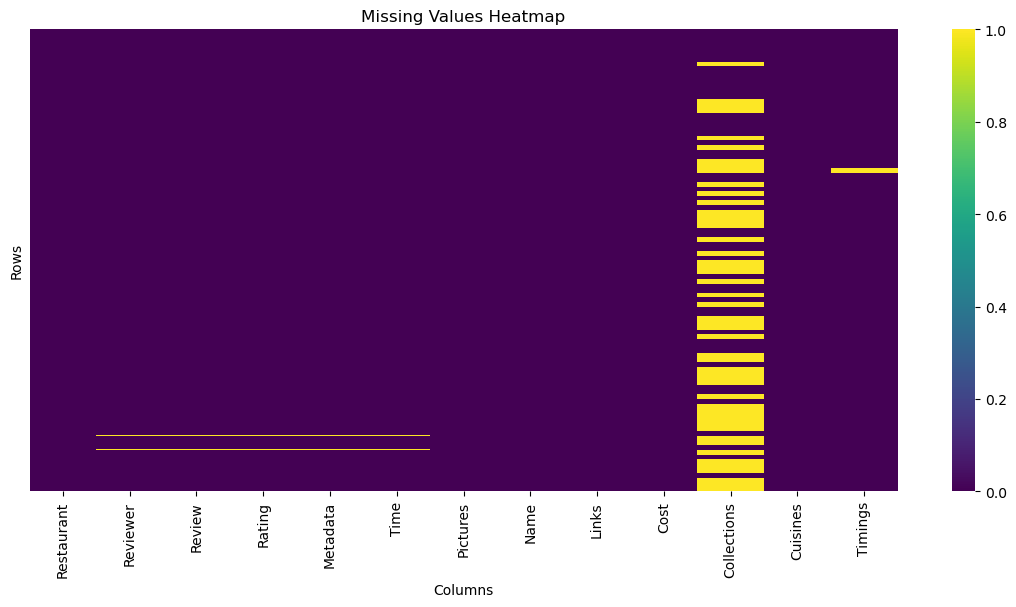

In [14]:
# Visualizing the missing values
plt.figure(figsize=(14,6))

sns.heatmap(final_reviews.isnull(), cmap='viridis', cbar=True, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

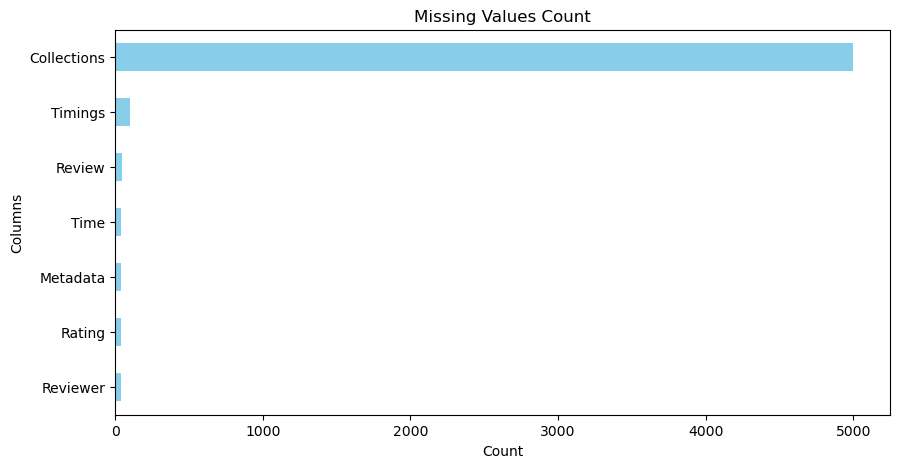

In [15]:
# Bar Chart
missing = final_reviews.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))

missing.sort_values().plot(
    kind='barh',
    color='skyblue'
)

plt.title("Missing Values Count")
plt.xlabel("Count")
plt.ylabel("Columns")

plt.show()

### What did you know about your dataset?

Answer :I worked with two Zomato datasets. The first one contains customer reviews, including the restaurant name, reviewer, review text, rating, review details, time, and number of pictures. The second dataset contains restaurant information such as cost, cuisine, collections, timings, and the Zomato link.
I merged both datasets using the restaurant name. After merging, the dataset had 10,000 rows and 13 columns. During the initial analysis, I found 36 duplicate records and some missing values. The Collections column had the highest number of missing values, with around 5,000 missing records, while Timings had 100 missing values. I also noticed a non-numeric value, Like, in the rating column, so I handled it during data cleaning.
For my project, the review text is one of the most important columns because I will use it for NLP and sentiment analysis. The rating is also important because I use it to create the sentiment categories. Overall, the dataset gives me a good combination of text, numerical, and categorical data, which allows me to perform both data analysis and machine learning.

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
print(final_reviews.columns.tolist())

['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


In [17]:
# Dataset Describe
display(final_reviews.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0
Name,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Links,10000,100,https://www.zomato.com/hyderabad/beyond-flavou...,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost,10000,28,500,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

Answer: I divided the variables in my dataset into different groups based on the type of information they contain. The first group is related to customer reviews, which includes the restaurant name, reviewer, review text, rating, review metadata, time, and pictures.The second group contains restaurant-related information, such as the restaurant name, Zomato link, cost, collections, cuisines, and timings.
Among these variables, the Review column is especially important because I will use it for NLP and sentiment analysis. The Rating column is also important because I use the ratings to create the sentiment categories. Cost and Pictures can be used as numerical features, while Cuisines, Collections, and Timings help me understand the restaurant and customer experience from a business perspective.
So, the dataset gives me a combination of customer feedback and restaurant information, which makes it useful for both data analysis and machine learning.

### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.
unique_counts = final_reviews.nunique(dropna=False).sort_values()
display(unique_counts.to_frame("Unique Values"))

,Unique Values
Rating,11
Cost,28
Pictures,36
Collections,43
Timings,75
Cuisines,89
Restaurant,100
Name,100
Links,100
Metadata,2478


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# write your code to make your dataset analysis ready.
# work on a copy so the original merged dataset remains available for reference.
df = final_reviews.copy()

In [21]:
# 1.Remove exact duplicate records.
df = df.drop_duplicates().copy()

In [24]:
# 2.Convert rating and cost to numeric values.

# the source rating contains one non-numeric value ("Like"), which becomes NaN.
df["Rating_num"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Cost_num"] = pd.to_numeric(
    df["Cost"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

In [25]:
# 3.Clean the review field enough for EDA.
df["Review_clean"] = df["Review"].fillna("").astype(str).str.strip()

In [26]:
# 4.fill descriptive missing metadata rather than deleting large numbers of rows.
df["Collections"] = df["Collections"].fillna("No Collection")
df["Timings"] = df["Timings"].fillna("Not Available")
df["Reviewer"] = df["Reviewer"].fillna("Unknown Reviewer")
df["Metadata"] = df["Metadata"].fillna("No Metadata")
df["Time"] = df["Time"].fillna("Unknown Time")

In [28]:
# 5.keep only rows that can support the ML objective.
# A sentiment label needs a valid rating and a non-empty review.
df = df.dropna(subset=["Rating_num"]).copy()
df = df[df["Review_clean"].str.len() > 0].copy()

In [29]:
# 6.create useful review-level features.
df["Review_Length"] = df["Review_clean"].str.len()
df["Word_Count"] = df["Review_clean"].str.split().str.len()

In [31]:
# 8.create a cost group for business analysis.
df["Cost_Group"] = pd.cut(
    df["Cost_num"],
    bins=[-1, 500, 1000, 1500, 2000, np.inf],
    labels=["<=500", "501-1000", "1001-1500", "1501-2000", ">2000"]
)

In [32]:
print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (9954, 19)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings,Rating_num,Cost_num,Review_clean,Review_Length,Word_Count,Cost_Group
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",5.0,800,"The ambience was good, food was quite good . h...",222,41,501-1000
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",5.0,800,Ambience is too good for a pleasant evening. S...,144,27,501-1000
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",5.0,800,A must try.. great food great ambience. Thnx f...,189,31,501-1000
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",5.0,800,Soumen das and Arun was a great guy. Only beca...,148,28,501-1000
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",5.0,800,Food is good.we ordered Kodi drumsticks and ba...,160,27,501-1000


### What all manipulations have you done and insights you found?

Answer: first, I cleaned the dataset by removing duplicate records because duplicates can affect the accuracy of my analysis. Then, I converted the Rating and Cost columns into numeric values. This was necessary because the Rating column had a non-numeric value like Like, and the Cost values were originally stored as text.
for the missing values, I tried not to remove too many records. For example, the Collections column had around 5,000 missing values, so instead of deleting those rows, I replaced the missing values with No Collection. For other descriptive columns, I used values like Unknown or Not Available wherever appropriate.
for the machine learning part, I removed the records where the review or rating was missing because I need both of them for sentiment analysis. I also created a few new features, such as Review_Length, Word_Count, and Cost_Group. Based on the ratings, I created three sentiment categories: Positive, Neutral, and Negative. After cleaning, I had around 9,954 usable records for the ML model.
When I checked the sentiment distribution, I found that around 63% of the reviews were Positive, 24% were Negative, and 12% were Neutral. So, the dataset is somewhat imbalanced. Because of this, I used class weighting and evaluation metrics like Macro F1-score instead of relying only on accuracy.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

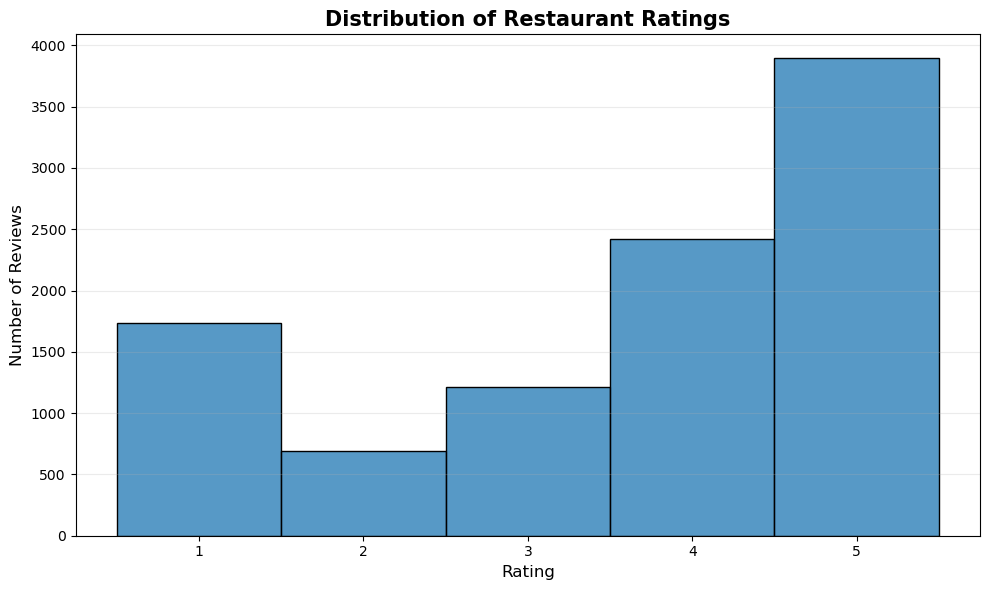

In [38]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Rating_num",
    bins=np.arange(0.75, 5.26, 0.25),
    discrete=True
)
plt.title("Distribution of Restaurant Ratings", fontsize=15, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer: I chose a histogram because rating is a numerical/ordinal variable and I wanted to see how customer ratings are distributed. The plot makes it easy to identify whether ratings are concentrated around high or low values.

##### 2. What is/are the insight(s) found from the chart?

Answer: The dataset is strongly concentrated at the higher end of the scale. The most common rating is 5, followed by 4. Ratings of 1 are also substantial, which means the dataset contains both strong positive and strong negative customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer:This is useful for restaurants because it shows that positive experiences are common, but the sizeable low-rating group should not be ignored. Negative reviews can point to service, food quality, or consistency problems that need attention.

#### Chart - 2

Sentiment distribution:
Sentiment
Positive    6315
Negative    2428
Neutral     1211
Name: count, dtype: int64


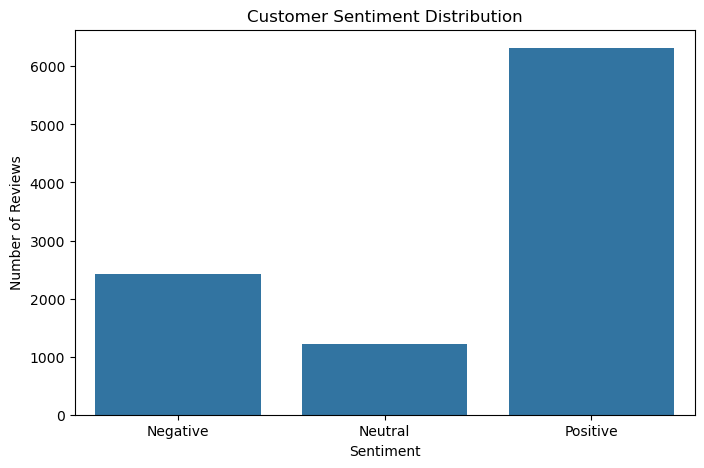

In [42]:
# Create sentiment labels from ratings

df["Sentiment"] = pd.cut(
    df["Rating_num"],
    bins=[-np.inf, 2, 3, 5],
    labels=["Negative", "Neutral", "Positive"]
)

print("Sentiment distribution:")
print(df["Sentiment"].value_counts())

sentiment_counts = df["Sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"])
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

##### 1. Why did you pick the specific chart?

Answer:A bar chart is suitable because sentiment is categorical. It gives a quick comparison of the three derived sentiment groups.

##### 2. What is/are the insight(s) found from the chart?

Answer:From the chart, I found that around 63.4% of the reviews are Positive, 24.4% are Negative, and 12.2% are Neutral. So, most of the reviews are positive, while Neutral reviews are comparatively fewer. This also shows that my dataset is somewhat imbalanced, which I need to consider when building and evaluating the machine learning model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: The positive majority is useful for understanding what customers generally like, but it also means a model could become biased toward Positive predictions. That is why I use class weighting and macro F1-score during model selection.

#### Chart - 3

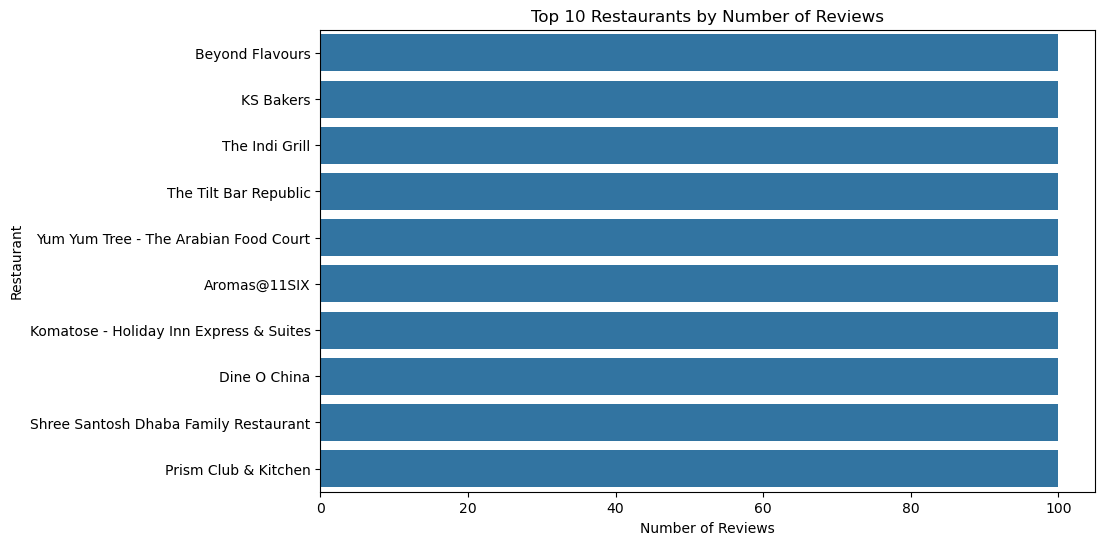

In [47]:
# Chart - 3 visualization code
top_restaurants = df["Restaurant"].value_counts().head(10).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title("Top 10 Restaurants by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: I selected a horizontal bar chart because restaurant names are long categorical labels and the chart makes the ranking easier to read.

##### 2. What is/are the insight(s) found from the chart?

Answer: The review dataset contains 100 reviews per restaurant for the restaurants represented in the source data, so the top restaurants have around 100 review records. This also shows that the source dataset is structured rather than a naturally occurring sample of review volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: The chart is useful for understanding the coverage of the dataset, but the equal review counts mean review volume should not be interpreted as real-world popularity. It is better to use this dataset for sentiment and rating analysis rather than claiming that one restaurant is more popular than another from review count alone.

#### Chart - 4

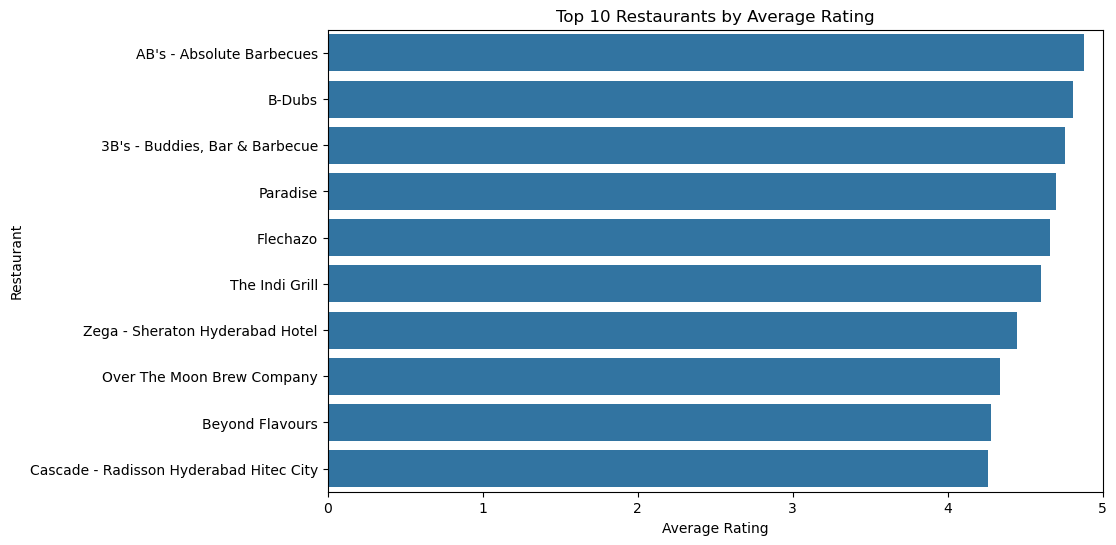

In [44]:
# Chart - 4 visualization code
restaurant_ratings = (
    df.groupby("Restaurant")["Rating_num"]
      .agg(["mean", "count"])
      .query("count >= 50")
      .sort_values("mean", ascending=False)
      .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x=restaurant_ratings["mean"], y=restaurant_ratings.index)
plt.title("Top 10 Restaurants by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")
plt.xlim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?

Answer: I used a bar chart after applying a minimum of 50 records per restaurant. This avoids ranking restaurants using only a very small number of reviews.

##### 2. What is/are the insight(s) found from the chart?

Answer: The highest average ratings are led by AB's - Absolute Barbecues (4.88), B-Dubs (4.81), and 3B's - Buddies, Bar & Barbecue (4.76). The results provide a practical shortlist of restaurants with consistently strong ratings in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: High-rated restaurants can be studied for their strengths in food, service, and ambience. However, the ranking reflects this dataset only and should not be treated as a current Zomato ranking.

#### Chart - 5

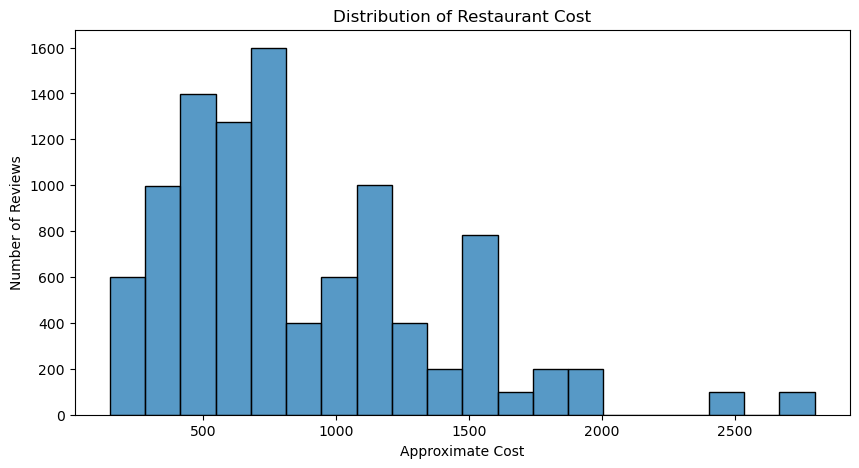

In [45]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df["Cost_num"], bins=20)
plt.title("Distribution of Restaurant Cost")
plt.xlabel("Approximate Cost")
plt.ylabel("Number of Reviews")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: Cost is numerical, so a histogram is a simple way to understand the price distribution before comparing cost with customer ratings.

##### 2. What is/are the insight(s) found from the chart?

Answer: The cost values range from about 150 to 2,800, with an average around 872. Most observations are in the lower and middle price ranges, while a smaller number of restaurants are more expensive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: Understanding the price distribution helps restaurants position their offerings. It also provides context when comparing ratings because a high rating at a higher price may represent a different customer expectation from a high rating at a low price.

#### Chart - 6

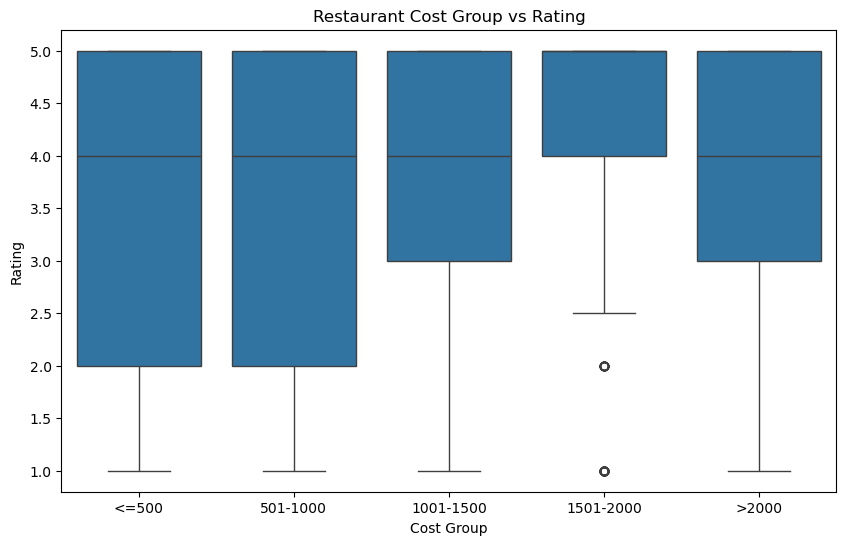

In [48]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Cost_Group", y="Rating_num")
plt.title("Restaurant Cost Group vs Rating")
plt.xlabel("Cost Group")
plt.ylabel("Rating")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A box plot is appropriate because it compares the distribution of a numerical variable, rating, across categorical cost groups. It shows the median, spread, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer: Average ratings generally increase from the lower-cost groups toward the 1,501–2,000 group. The relationship is not perfectly linear, but the correlation between cost and rating is positive and weak at about 0.14.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: The result suggests that price alone does not determine customer satisfaction. Restaurants should not assume that increasing price will automatically improve ratings; food quality and service still need to support the price.

#### Chart - 7

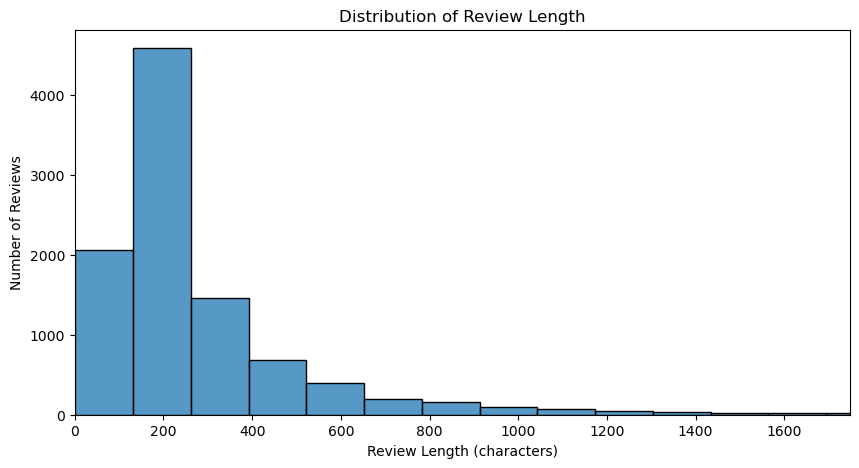

In [49]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df["Review_Length"], bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.xlim(0, df["Review_Length"].quantile(0.99))
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A histogram shows the shape of the review-length distribution and helps identify unusually long reviews that may affect text preprocessing.

##### 2. What is/are the insight(s) found from the chart?

Answer: Most reviews are relatively short, but the distribution has a long right tail. The median review length is about 189 characters, while a small number of reviews are much longer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: Long reviews can contain more detailed feedback, which is useful for text analysis. However, extreme lengths can add noise, so reviewing text length is useful before NLP preprocessing.

#### Chart - 8

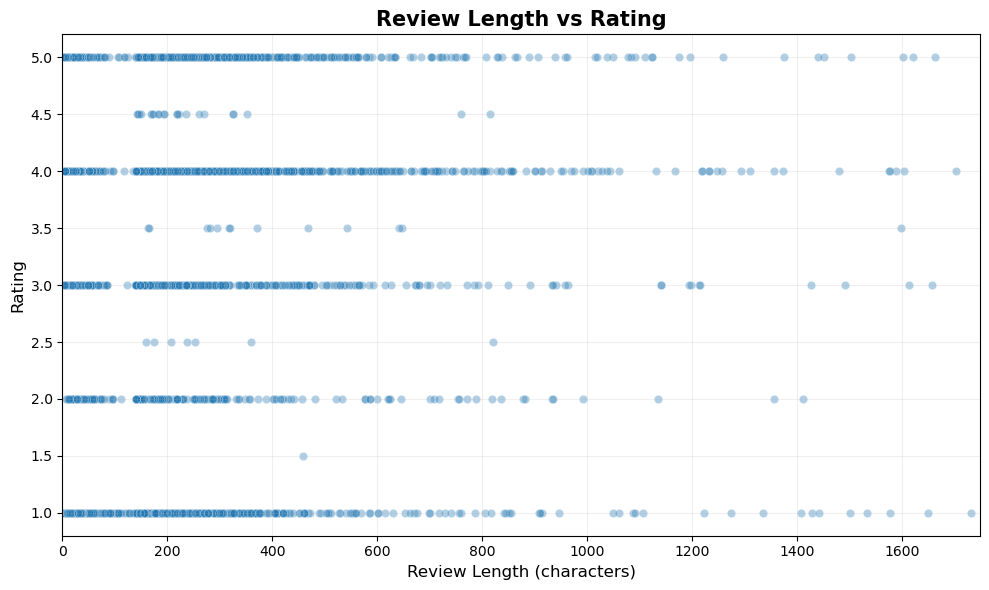

In [51]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(3000, len(df))),
    x="Review_Length",
    y="Rating_num",
    alpha=0.35
)

plt.title("Review Length vs Rating", fontsize=15, fontweight="bold")
plt.xlabel("Review Length (characters)", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.grid(axis="both", alpha=0.2)
plt.xlim(0, df["Review_Length"].quantile(0.99))

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A scatter plot is useful for checking whether there is a visible relationship between two numerical variables: review length and rating.

##### 2. What is/are the insight(s) found from the chart?

Answer: The relationship is weakly negative, with a correlation around -0.03 after cleaning. In other words, review length alone is not a strong predictor of rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: This is useful because it prevents an unnecessary business assumption that longer reviews are always better or worse. The text content itself is more informative than length alone, which supports the use of NLP features.

#### Chart - 9

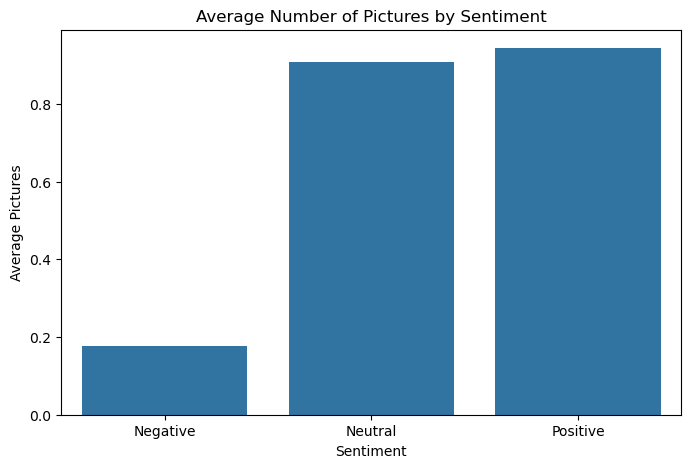

In [52]:
# Chart - 9 visualization code
picture_sentiment = df.groupby("Sentiment", observed=True)["Pictures"].mean().reindex(
    ["Negative", "Neutral", "Positive"]
)
plt.figure(figsize=(8, 5))
sns.barplot(x=picture_sentiment.index, y=picture_sentiment.values)
plt.title("Average Number of Pictures by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Pictures")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A bar chart makes it easy to compare average picture counts across the three sentiment groups.

##### 2. What is/are the insight(s) found from the chart?

Answer: Positive reviews have the highest average number of pictures, around 0.94 per review, while negative reviews average only around 0.18. Neutral reviews are in between.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: This may indicate that customers with positive experiences are more likely to share photos. For restaurants, encouraging visual content can help showcase positive experiences, although the relationship is an association rather than proof of causation.

#### Chart - 10

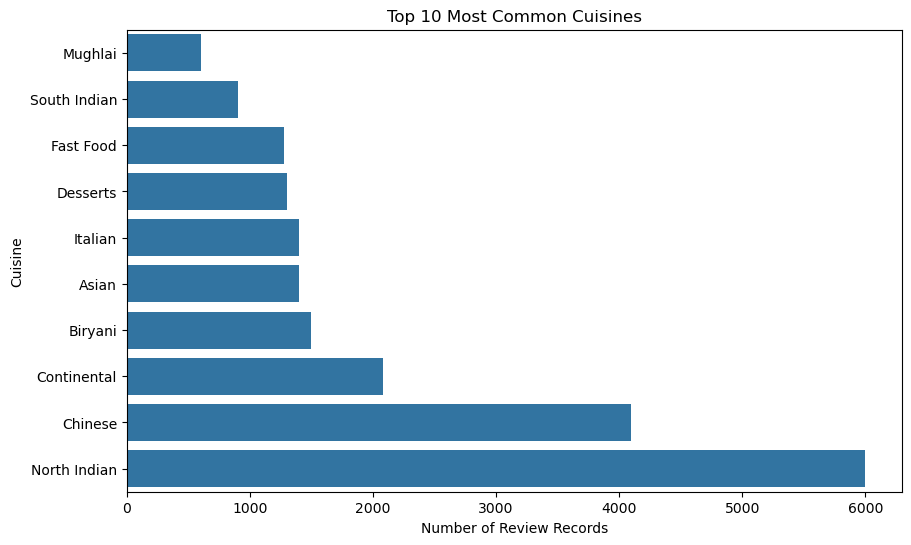

In [53]:
# Chart - 10 visualization code
cuisine_long = df[["Cuisines"]].dropna().copy()
cuisine_long["Cuisine"] = cuisine_long["Cuisines"].str.split(",")
cuisine_long = cuisine_long.explode("Cuisine")
cuisine_long["Cuisine"] = cuisine_long["Cuisine"].str.strip()
top_cuisines = cuisine_long["Cuisine"].value_counts().head(10).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Review Records")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A horizontal bar chart is appropriate for ranking categorical cuisine names by frequency.

##### 2. What is/are the insight(s) found from the chart?

Answer: North Indian is the most common cuisine in the dataset, followed by Chinese and Continental. Biryani, Asian, Italian, Desserts, and Fast Food also appear frequently.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: Cuisine popularity can help restaurants understand which food categories are strongly represented in the dataset. It can support menu positioning and competitor analysis, while recognizing that the dataset is limited to the restaurants included in the source files.

#### Chart - 11

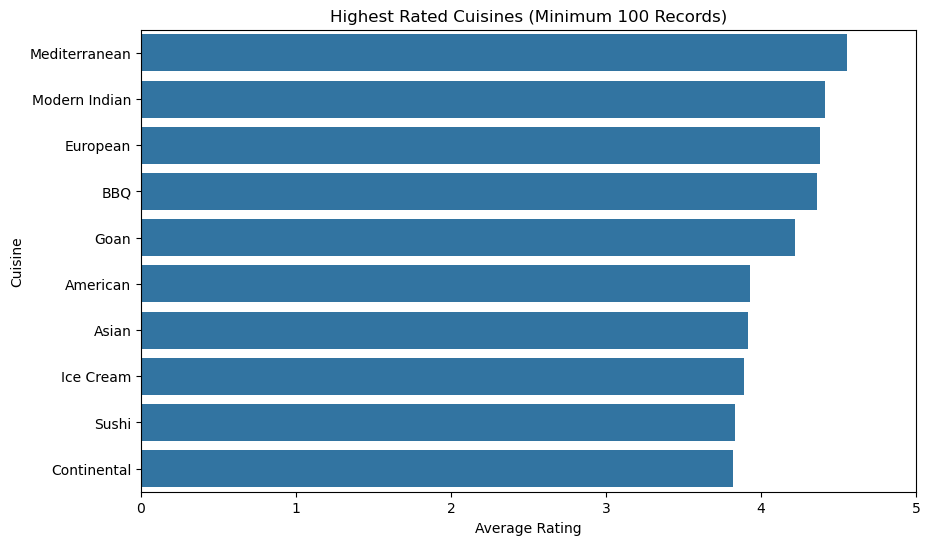

In [54]:
# Chart - 11 visualization code
cuisine_rating = (
    df[["Cuisines", "Rating_num"]].dropna().assign(
        Cuisine=lambda x: x["Cuisines"].str.split(",")
    ).explode("Cuisine")
)
cuisine_rating["Cuisine"] = cuisine_rating["Cuisine"].str.strip()
cuisine_rating = (
    cuisine_rating.groupby("Cuisine")["Rating_num"]
    .agg(["mean", "count"])
    .query("count >= 100")
    .sort_values("mean", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x=cuisine_rating["mean"], y=cuisine_rating.index)
plt.title("Highest Rated Cuisines (Minimum 100 Records)")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.xlim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?

Answer: I used a bar chart to compare average ratings for cuisines with at least 100 records. The minimum-count filter makes the comparison more reliable.

##### 2. What is/are the insight(s) found from the chart?

Answer: Mediterranean has the highest average rating among the displayed cuisines at about 4.55, followed by Modern Indian at about 4.41 and European at about 4.38.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: These patterns can help restaurants identify cuisine categories associated with strong customer satisfaction. They are useful for hypothesis generation, not proof that a cuisine itself causes higher satisfaction.

#### Chart - 12

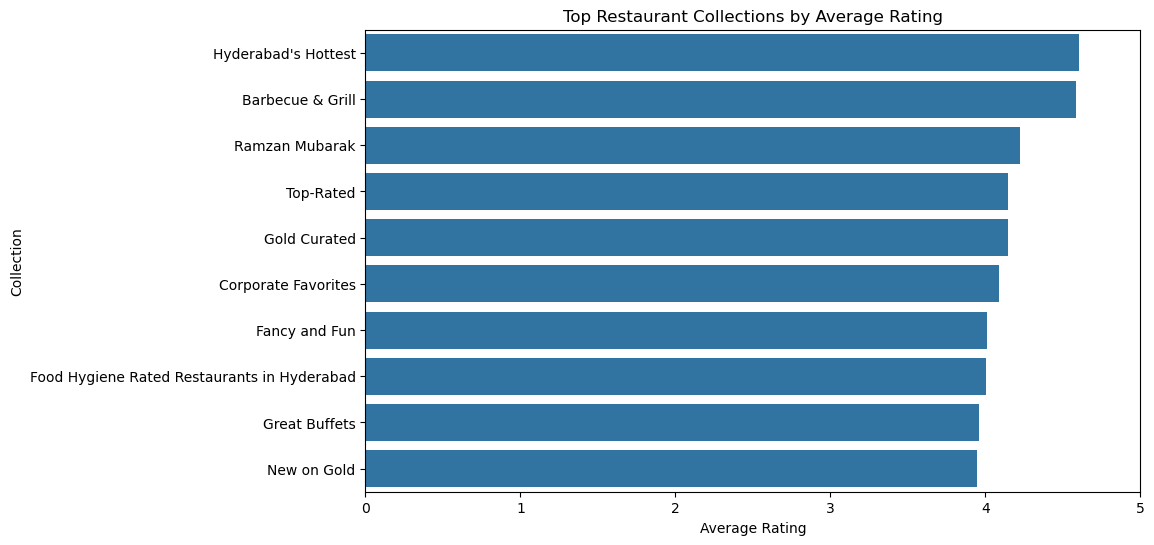

In [55]:
# Chart - 12 visualization code
collection_long = df[["Collections", "Rating_num"]].copy()
collection_long["Collection"] = collection_long["Collections"].str.split(",")
collection_long = collection_long.explode("Collection")
collection_long["Collection"] = collection_long["Collection"].str.strip()
collection_rating = (
    collection_long.groupby("Collection")["Rating_num"]
    .agg(["mean", "count"])
    .query("count >= 100")
    .sort_values("mean", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x=collection_rating["mean"], y=collection_rating.index)
plt.title("Top Restaurant Collections by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Collection")
plt.xlim(0, 5)
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A bar chart is useful for comparing the average rating of restaurant collections after splitting the collection field into individual collection labels.

##### 2. What is/are the insight(s) found from the chart?

Answer: Collections such as Hyderabad's Hottest, Top-Rated, and Gold Curated show high average ratings in this dataset. The `No Collection` group has a lower average rating of about 3.44.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: Collection membership may act as a useful business signal because curated or high-performing restaurants appear to have stronger ratings. However, collection membership is an editorial/metadata attribute, so it should not be interpreted as a causal factor.

#### Chart - 13

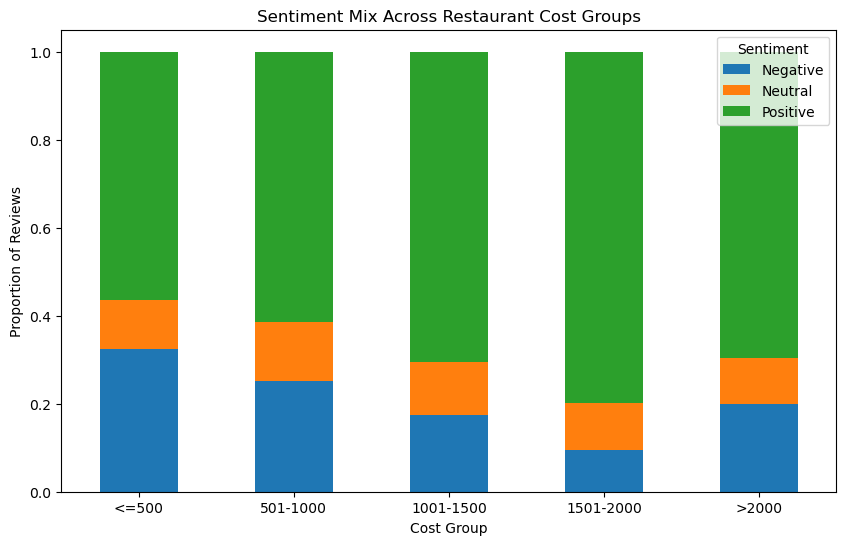

In [56]:
# Chart - 13 visualization code
cost_sentiment = pd.crosstab(
    df["Cost_Group"], df["Sentiment"], normalize="index"
).reindex(columns=["Negative", "Neutral", "Positive"])
cost_sentiment.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment Mix Across Restaurant Cost Groups")
plt.xlabel("Cost Group")
plt.ylabel("Proportion of Reviews")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A stacked bar chart is useful because it compares the composition of Negative, Neutral, and Positive reviews across price groups rather than only comparing average ratings.

##### 2. What is/are the insight(s) found from the chart?

Answer: The sentiment mix changes across cost groups. The higher-cost groups generally contain a larger share of Positive reviews, which is consistent with the weak positive cost-rating relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer: This can help restaurants benchmark customer sentiment across price segments. The negative share still exists in every segment, showing that premium pricing does not remove the need to manage customer experience.

#### Chart - 14 - Correlation Heatmap

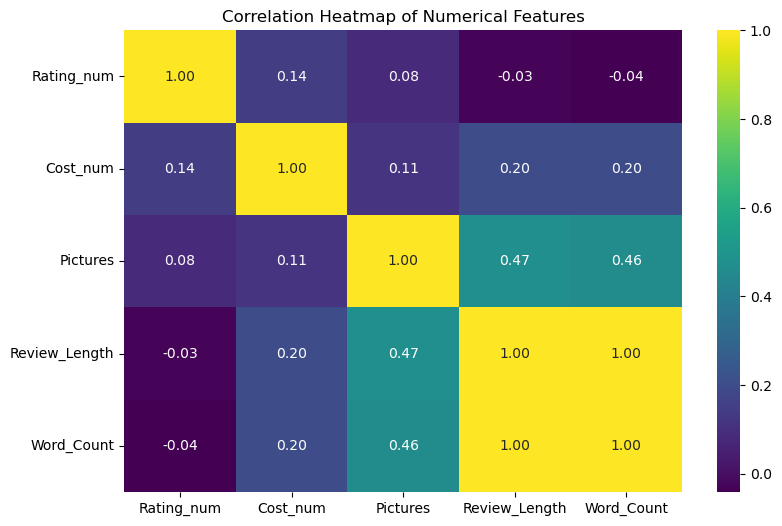

In [57]:
# Correlation Heatmap visualization code
numeric_cols = ["Rating_num", "Cost_num", "Pictures", "Review_Length", "Word_Count"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##### 1. Why did you pick the specific chart?

Answer: I selected a correlation heatmap because it summarizes pairwise linear relationships among several numerical variables in one view.

##### 2. What is/are the insight(s) found from the chart?

Answer: Cost and rating have a weak positive correlation of about 0.14. Review length and rating are almost unrelated at about -0.03, while pictures and rating have a small positive correlation of about 0.08. These results show that no single numerical variable strongly explains rating.

#### Chart - 15 - Pair Plot

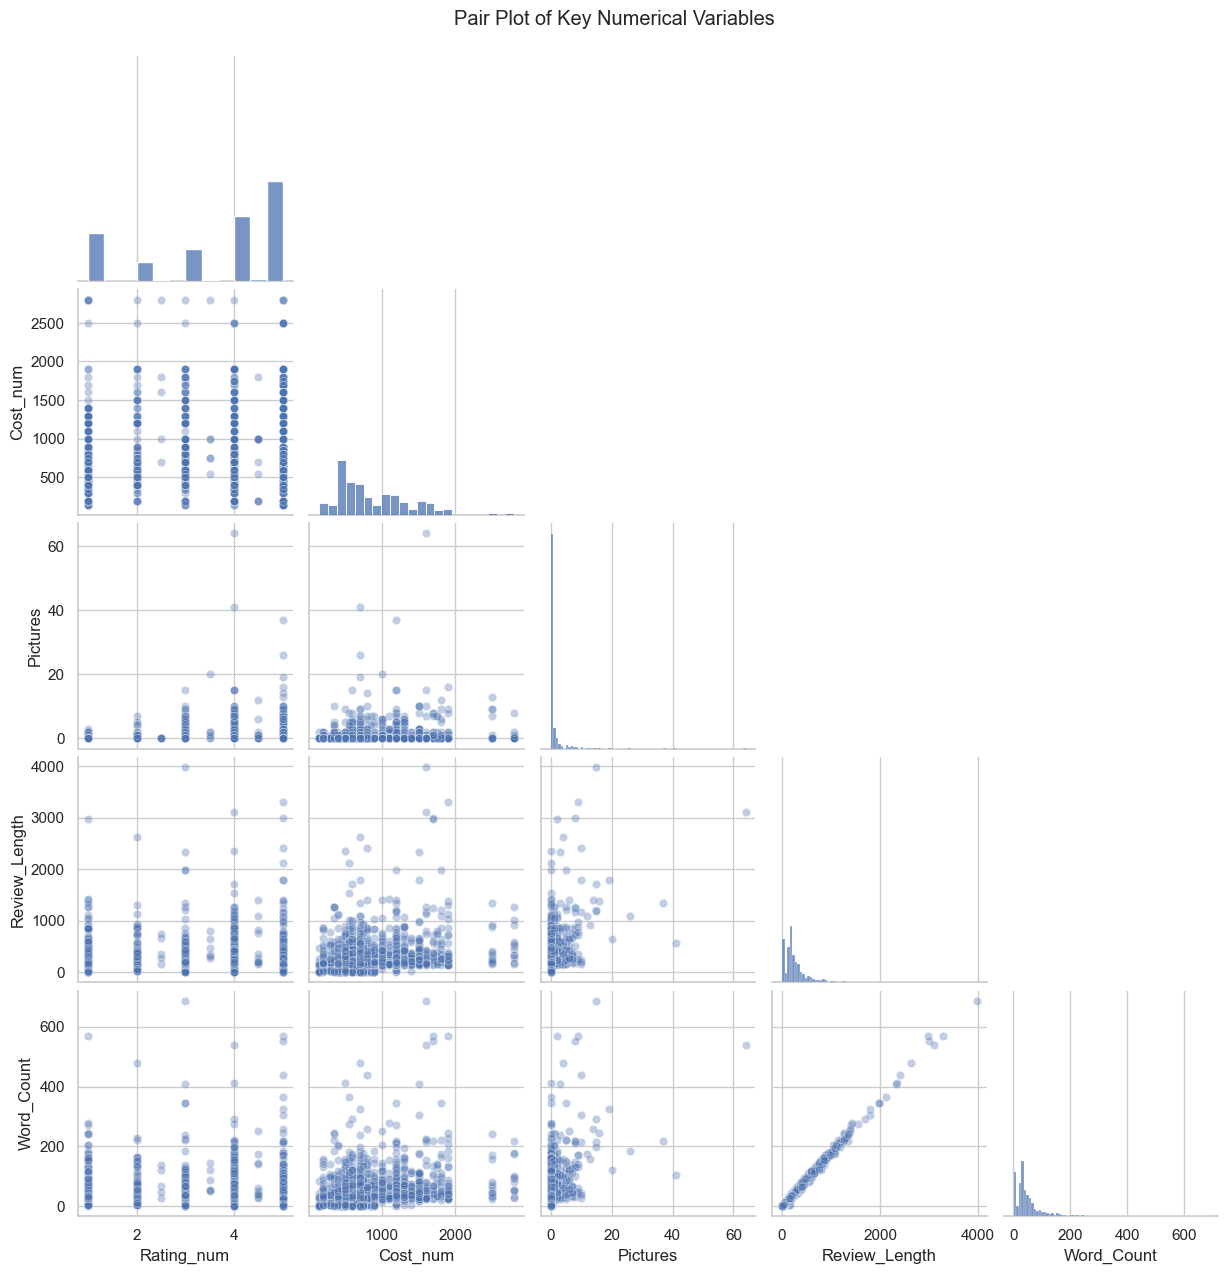

In [69]:
# Pair Plot visualization code
pair_data = df[["Rating_num", "Cost_num", "Pictures", "Review_Length", "Word_Count"]].copy()
pair_sample = pair_data.sample(min(1500, len(pair_data)), random_state=RANDOM_STATE)
sns.pairplot(pair_sample, corner=True, plot_kws={"alpha": 0.35})
plt.suptitle("Pair Plot of Key Numerical Variables", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Answer: A pair plot gives a broader multivariate view of the relationships among rating, cost, pictures, review length, and word count. I used a sample to keep the visualization readable and computationally manageable.

##### 2. What is/are the insight(s) found from the chart?

Answer: The pair plot supports the correlation findings: the numerical variables do not form strong, clean linear relationships. Rating appears more strongly influenced by the content of reviews and restaurant context than by simple numerical variables alone.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer: After exploring the dataset, I came up with three questions that I felt were useful from a business point of view. First, I wanted to check whether expensive restaurants receive higher or lower ratings compared to less expensive restaurants. Second, I wanted to see whether customers who leave positive reviews are more likely to upload pictures. Finally, I wanted to understand if the length of a review has any relationship with the rating given by the customer.
Instead of depending only on the charts, I used statistical tests to check whether these relationships were actually significant or just happened by chance.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer: For this test, my null hypothesis is that there is no difference in the average ratings between higher-cost and lower-cost restaurants. In other words, I assume that the restaurant price does not make a significant difference in the average rating.

My alternative hypothesis is that there is a significant difference in the average ratings between the two groups. I will use the statistical test and p-value to decide which hypothesis is supported by the data.

#### 2. Perform an appropriate statistical test.

In [70]:
# Perform Statistical Test to obtain P-Value
median_cost = df["Cost_num"].median()
high_cost_ratings = df.loc[df["Cost_num"] > median_cost, "Rating_num"].dropna()
low_cost_ratings = df.loc[df["Cost_num"] <= median_cost, "Rating_num"].dropna()

t_stat, p_value = stats.ttest_ind(
    high_cost_ratings,
    low_cost_ratings,
    equal_var=False
)

print("Median cost:", median_cost)
print("High-cost mean rating:", round(high_cost_ratings.mean(), 3))
print("Low-cost mean rating:", round(low_cost_ratings.mean(), 3))
print("Welch t-statistic:", round(t_stat, 3))
print("P-value:", p_value)
print("Conclusion:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

Median cost: 700.0
High-cost mean rating: 3.785
Low-cost mean rating: 3.422
Welch t-statistic: 12.303
P-value: 1.5571332377228019e-34
Conclusion: Reject H0


##### Which statistical test have you done to obtain P-Value?

Answer: I used Welch's independent two-sample t-test.

##### Why did you choose the specific statistical test?

Answer: I chose Welch's t-test because I am comparing the means of two independent groups and I do not want to assume that the two groups have exactly equal variances. The very small p-value indicates a statistically significant difference between the average ratings of the two cost groups.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer: **Null hypothesis (H0):** Positive reviews and non-Positive reviews have the same distribution of picture counts.

**Alternative hypothesis (H1):** Positive reviews and non-Positive reviews have different distributions of picture counts.

#### 2. Perform an appropriate statistical test.

In [71]:
# Perform Statistical Test to obtain P-Value
positive_pictures = df.loc[df["Sentiment"] == "Positive", "Pictures"].dropna()
non_positive_pictures = df.loc[df["Sentiment"] != "Positive", "Pictures"].dropna()

u_stat, p_value_2 = stats.mannwhitneyu(
    positive_pictures,
    non_positive_pictures,
    alternative="two-sided"
)

print("Positive reviews mean pictures:", round(positive_pictures.mean(), 3))
print("Non-positive reviews mean pictures:", round(non_positive_pictures.mean(), 3))
print("Mann-Whitney U statistic:", u_stat)
print("P-value:", p_value_2)
print("Conclusion:", "Reject H0" if p_value_2 < 0.05 else "Fail to reject H0")

Positive reviews mean pictures: 0.943
Non-positive reviews mean pictures: 0.42
Mann-Whitney U statistic: 12531571.5
P-value: 2.8059279599434256e-27
Conclusion: Reject H0


##### Which statistical test have you done to obtain P-Value?

Answer: I used the Mann-Whitney U test.

##### Why did you choose the specific statistical test?

Answer: Picture counts are discrete and heavily concentrated at zero, so a normality assumption is not appropriate. The Mann-Whitney U test is a non-parametric alternative for comparing two independent groups. The very small p-value indicates a statistically significant difference in picture counts.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer: **Null hypothesis (H0):** There is no monotonic association between review length and rating.

**Alternative hypothesis (H1):** There is a monotonic association between review length and rating.

#### 2. Perform an appropriate statistical test.

In [72]:
# Perform Statistical Test to obtain P-Value
spearman_data = df[["Review_Length", "Rating_num"]].dropna()

spearman_corr, p_value_3 = stats.spearmanr(
    spearman_data["Review_Length"],
    spearman_data["Rating_num"]
)

print("Spearman correlation:", round(spearman_corr, 4))
print("P-value:", p_value_3)
print("Conclusion:", "Reject H0" if p_value_3 < 0.05 else "Fail to reject H0")

Spearman correlation: -0.1248
P-value: 7.2301640193414e-36
Conclusion: Reject H0


##### Which statistical test have you done to obtain P-Value?

Answer: I used Spearman's rank correlation test.

##### Why did you choose the specific statistical test?

Answer: I chose Spearman correlation because review length and rating are not guaranteed to have a linear relationship and rating is ordinal in nature. The p-value is very small, so the null hypothesis is rejected. However, the correlation magnitude is only about -0.13, so the relationship is statistically significant but weak in practical terms.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [73]:
# Handling Missing Values & Missing Value Imputation

print("Missing values after cleaning:")
display(df[["Reviewer", "Review", "Rating_num", "Metadata", "Time", "Timings", "Collections"]].isnull().sum())

Missing values after cleaning:


Reviewer       0
Review         0
Rating_num     0
Metadata       0
Time           0
Timings        0
Collections    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer: I used different strategies based on the meaning of each column. Descriptive text fields such as `Collections`, `Timings`, `Reviewer`, `Metadata`, and `Time` were filled with labels such as `No Collection`, `Not Available`, or `Unknown`. I did not impute missing ratings because the rating is the source of the sentiment label; inventing a rating could create incorrect training labels. Rows without a valid rating or usable review text were therefore excluded from the ML dataset.

### 2. Handling Outliers

In [74]:
# Handling Outliers & Outlier treatments
length_99 = df["Review_Length"].quantile(0.99)
print("99th percentile of review length:", round(length_99, 2))
print("Maximum review length:", df["Review_Length"].max())

99th percentile of review length: 1747.82
Maximum review length: 5212


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer: I did not aggressively remove outliers from the main dataset. A very long review can be a genuine and useful customer comment, so deleting it would lose information. For charts, I used the 99th percentile only as a display limit so that a few extremely long reviews do not compress the rest of the distribution.

### 3. Categorical Encoding

In [75]:
# Encode your categorical columns
label_encoder = LabelEncoder()
df["Sentiment_Code"] = label_encoder.fit_transform(df["Sentiment"])

print("Sentiment classes:", list(label_encoder.classes_))
display(df[["Sentiment", "Sentiment_Code"]].drop_duplicates().sort_values("Sentiment_Code"))

Sentiment classes: ['Negative', 'Neutral', 'Positive']


,Sentiment,Sentiment_Code
14,Negative,0
30,Neutral,1
0,Positive,2


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer: The main model input is text, so one-hot encoding of high-cardinality columns such as restaurant name was not necessary for the final NLP model. For the target variable, I used `LabelEncoder` to convert Negative, Neutral, and Positive into numeric class labels. This is appropriate because the target is categorical and the encoding is used only for the classification workflow.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [76]:
# Expand Contraction
contractions = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    text = str(text)
    for contraction, replacement in contractions.items():
        text = re.sub(re.escape(contraction), replacement, text, flags=re.IGNORECASE)
    return text

df["Review_Expanded"] = df["Review_clean"].apply(expand_contractions)
print(df["Review_Expanded"].head(3).to_list())

['The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was really courteous and helpful.', 'Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service', 'A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.']


#### 2. Lower Casing

In [77]:
# Lower Casing
df["Review_Lower"] = df["Review_Expanded"].str.lower()
print(df["Review_Lower"].head(3).to_list())

['the ambience was good, food was quite good . had saturday lunch , which was cost effective .\ngood place for a sate brunch. one can also chill with friends and or parents.\nwaiter soumen das was really courteous and helpful.', 'ambience is too good for a pleasant evening. service is very prompt. food is good. over all a good experience. soumen das - kudos to the service', 'a must try.. great food great ambience. thnx for the service by pradeep and subroto. my personal recommendation is penne alfredo pasta:) ....... also the music in the background is amazing.']


#### 3. Removing Punctuations

In [78]:
# Remove Punctuations
df["Review_No_Punctuation"] = df["Review_Lower"].str.replace(
    f"[{re.escape(string.punctuation)}]",
    " ",
    regex=True
)
print(df["Review_No_Punctuation"].head(3).to_list())

['the ambience was good  food was quite good   had saturday lunch   which was cost effective  \ngood place for a sate brunch  one can also chill with friends and or parents \nwaiter soumen das was really courteous and helpful ', 'ambience is too good for a pleasant evening  service is very prompt  food is good  over all a good experience  soumen das   kudos to the service', 'a must try   great food great ambience  thnx for the service by pradeep and subroto  my personal recommendation is penne alfredo pasta           also the music in the background is amazing ']


#### 4. Removing URLs & Removing words and digits contain digits.

In [79]:
# Remove URLs & Remove words and digits contain digits
def remove_urls_and_digit_words(text):
    text = re.sub(r"https?://\S+|www\.\S+", " ", str(text))
    text = re.sub(r"\b\w*\d\w*\b", " ", text)
    return text

df["Review_No_URL_Digits"] = df["Review_No_Punctuation"].apply(remove_urls_and_digit_words)
print(df["Review_No_URL_Digits"].head(3).to_list())

['the ambience was good  food was quite good   had saturday lunch   which was cost effective  \ngood place for a sate brunch  one can also chill with friends and or parents \nwaiter soumen das was really courteous and helpful ', 'ambience is too good for a pleasant evening  service is very prompt  food is good  over all a good experience  soumen das   kudos to the service', 'a must try   great food great ambience  thnx for the service by pradeep and subroto  my personal recommendation is penne alfredo pasta           also the music in the background is amazing ']


#### 5. Removing Stopwords & Removing White spaces

In [80]:
# Remove Stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    tokens = str(text).split()
    return " ".join(token for token in tokens if token not in stop_words)

df["Review_No_Stopwords"] = df["Review_No_URL_Digits"].apply(remove_stopwords)
print(df["Review_No_Stopwords"].head(3).to_list())

['ambience good food quite good saturday lunch cost effective good place sate brunch chill friends parents waiter soumen das really courteous helpful', 'ambience good pleasant evening service prompt food good good experience soumen das kudos service', 'try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta music background amazing']


In [81]:
# Remove White spaces
df["Review_No_Whitespace"] = df["Review_No_Stopwords"].str.replace(r"\s+", " ", regex=True).str.strip()
print(df["Review_No_Whitespace"].head(3).to_list())

['ambience good food quite good saturday lunch cost effective good place sate brunch chill friends parents waiter soumen das really courteous helpful', 'ambience good pleasant evening service prompt food good good experience soumen das kudos service', 'try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta music background amazing']


#### 6. Rephrase Text

In [82]:
# Rephrase Text
def normalize_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", str(text))

df["Review_Rephrased"] = df["Review_No_Whitespace"].apply(normalize_repeated_characters)
print(df["Review_Rephrased"].head(3).to_list())

['ambience good food quite good saturday lunch cost effective good place sate brunch chill friends parents waiter soumen das really courteous helpful', 'ambience good pleasant evening service prompt food good good experience soumen das kudos service', 'try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta music background amazing']


#### 7. Tokenization

In [83]:
# Tokenization
def tokenize_text(text):
    return re.findall(r"\b[a-zA-Z]+\b", str(text))

df["Tokens"] = df["Review_Rephrased"].apply(tokenize_text)
print(df["Tokens"].head(3).to_list())

[['ambience', 'good', 'food', 'quite', 'good', 'saturday', 'lunch', 'cost', 'effective', 'good', 'place', 'sate', 'brunch', 'chill', 'friends', 'parents', 'waiter', 'soumen', 'das', 'really', 'courteous', 'helpful'], ['ambience', 'good', 'pleasant', 'evening', 'service', 'prompt', 'food', 'good', 'good', 'experience', 'soumen', 'das', 'kudos', 'service'], ['try', 'great', 'food', 'great', 'ambience', 'thnx', 'service', 'pradeep', 'subroto', 'personal', 'recommendation', 'penne', 'alfredo', 'pasta', 'music', 'background', 'amazing']]


#### 8. Text Normalization

In [84]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
try:
    from nltk.stem import WordNetLemmatizer, PorterStemmer
    lemmatizer = WordNetLemmatizer()
    stemmer = PorterStemmer()
    try:
        lemmatizer.lemmatize("testing")
        USE_LEMMATIZER = True
    except LookupError:
        USE_LEMMATIZER = False
except Exception:
    USE_LEMMATIZER = False

def normalize_tokens(tokens):
    if USE_LEMMATIZER:
        return [lemmatizer.lemmatize(token) for token in tokens]
    return [stemmer.stem(token) for token in tokens]

df["Normalized_Tokens"] = df["Tokens"].apply(normalize_tokens)
df["Processed_Review"] = df["Normalized_Tokens"].apply(lambda x: " ".join(x))

print("Lemmatization available:", USE_LEMMATIZER)
print(df["Processed_Review"].head(3).to_list())

Lemmatization available: False
['ambienc good food quit good saturday lunch cost effect good place sate brunch chill friend parent waiter soumen da realli courteou help', 'ambienc good pleasant even servic prompt food good good experi soumen da kudo servic', 'tri great food great ambienc thnx servic pradeep subroto person recommend penn alfredo pasta music background amaz']


##### Which text normalization technique have you used and why?

Answer: I used lemmatization when the required NLTK WordNet resource is available, with Porter stemming as a safe fallback. Lemmatization is preferred because it tries to convert words to meaningful base forms, which can reduce vocabulary size without changing the meaning as aggressively as some stemming rules.

#### 9. Part of speech tagging

In [85]:
# POS Taging
try:
    import nltk
    from nltk import pos_tag
    try:
        pos_tag(["food", "was", "excellent"])
        POS_AVAILABLE = True
    except LookupError:
        POS_AVAILABLE = False
except Exception:
    POS_AVAILABLE = False

def safe_pos_tag(tokens):
    if POS_AVAILABLE:
        try:
            return pos_tag(tokens)
        except Exception:
            pass
    # Safe fallback when the local NLTK tagger data is unavailable.
    return [(token, "NN") for token in tokens]

df["POS_Tags"] = df["Tokens"].apply(safe_pos_tag)
print(df["POS_Tags"].head(3).to_list())

[[('ambience', 'NN'), ('good', 'NN'), ('food', 'NN'), ('quite', 'NN'), ('good', 'NN'), ('saturday', 'NN'), ('lunch', 'NN'), ('cost', 'NN'), ('effective', 'NN'), ('good', 'NN'), ('place', 'NN'), ('sate', 'NN'), ('brunch', 'NN'), ('chill', 'NN'), ('friends', 'NN'), ('parents', 'NN'), ('waiter', 'NN'), ('soumen', 'NN'), ('das', 'NN'), ('really', 'NN'), ('courteous', 'NN'), ('helpful', 'NN')], [('ambience', 'NN'), ('good', 'NN'), ('pleasant', 'NN'), ('evening', 'NN'), ('service', 'NN'), ('prompt', 'NN'), ('food', 'NN'), ('good', 'NN'), ('good', 'NN'), ('experience', 'NN'), ('soumen', 'NN'), ('das', 'NN'), ('kudos', 'NN'), ('service', 'NN')], [('try', 'NN'), ('great', 'NN'), ('food', 'NN'), ('great', 'NN'), ('ambience', 'NN'), ('thnx', 'NN'), ('service', 'NN'), ('pradeep', 'NN'), ('subroto', 'NN'), ('personal', 'NN'), ('recommendation', 'NN'), ('penne', 'NN'), ('alfredo', 'NN'), ('pasta', 'NN'), ('music', 'NN'), ('background', 'NN'), ('amazing', 'NN')]]


#### 10. Text Vectorization

In [86]:
# Vectorizing Text
X_text = df["Processed_Review"]
y_text = df["Sentiment_Code"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_text
)

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (7963, 5000)
Testing TF-IDF shape: (1991, 5000)


##### Which text vectorization technique have you used and why?

Answer: I used TF-IDF because the project is based on restaurant review text. TF-IDF gives higher importance to words that are useful for distinguishing reviews while reducing the influence of words that appear very frequently across many reviews. I also used unigrams and bigrams so that short phrases can contribute to the prediction.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [87]:
# Manipulate Features to minimize feature correlation and create new features
df["Average_Word_Length"] = np.where(
    df["Word_Count"] > 0,
    df["Review_Length"] / df["Word_Count"],
    0
)

display(df[["Review_Length", "Word_Count", "Average_Word_Length"]].describe())

,Review_Length,Word_Count,Average_Word_Length
count,9954.000000,9954.000000,9954.000000
mean,279.777979,50.173297,5.582892
std,338.615629,60.786767,1.895037
min,1.000000,1.000000,1.000000
25%,144.000000,24.000000,5.240741
50%,189.000000,34.000000,5.542857
75%,321.000000,58.000000,5.880000
max,5212.000000,964.000000,170.000000


#### 2. Feature Selection

In [88]:
# Select your features wisely to avoid overfitting
k_features = min(3000, X_train_tfidf.shape[1])

selector = SelectKBest(score_func=chi2, k=k_features)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print("Features before selection:", X_train_tfidf.shape[1])
print("Features after selection:", X_train_selected.shape[1])

Features before selection: 5000
Features after selection: 3000


##### What all feature selection methods have you used  and why?

Answer: I used Chi-square feature selection because the TF-IDF matrix contains thousands of sparse text features. Keeping the strongest features reduces noise, speeds up model training, and can reduce overfitting. The selector is fitted only on the training set, which avoids data leakage.

##### Which all features you found important and why?

Answer: The most important features are words and short phrases that strongly distinguish Negative, Neutral, and Positive reviews. Examples are expected to include sentiment-bearing terms related to food quality, service, ambience, and experience. The exact feature importance is examined later using the coefficients of the final Linear SVC model.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [90]:
# Transform Your data
# No additional transformation is required for the target.
# Text has already been transformed into TF-IDF features.
print("Text transformation completed using TF-IDF.")

Text transformation completed using TF-IDF.


### 6. Data Scaling

In [91]:
# Scaling your data
# Additional standard scaling is not applied.
# TF-IDF produces normalized sparse values and linear text classifiers work directly with this representation.
print("Additional numerical scaling is not required for the TF-IDF model.")

Additional numerical scaling is not required for the TF-IDF model.


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer: Dimensionality reduction with PCA is not necessary here. TF-IDF already creates a high-dimensional sparse representation, and Chi-square feature selection reduces the feature space while keeping features that are directly useful for classification. PCA on sparse text data can also make the representation dense and less practical.

In [92]:
# DImensionality Reduction (If needed)
# PCA is intentionally not applied.
print("Dimensionality reduction skipped; Chi-square feature selection is used instead.")

Dimensionality reduction skipped; Chi-square feature selection is used instead.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer: No separate dimensionality-reduction algorithm was used. Chi-square feature selection was considered sufficient for this sparse NLP problem.

### 8. Data Splitting

In [93]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train_final, y_test_final = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_text
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 7963
Testing rows: 1991


##### What data splitting ratio have you used and why?

Answer: I used an 80:20 train-test split. Eighty percent gives the models enough examples to learn from, while twenty percent provides a separate set for an honest final evaluation. Stratification keeps the Positive, Neutral, and Negative class proportions similar in both sets.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer: Yes, the dataset is imbalanced. The cleaned data contains about 63.4% Positive, 24.4% Negative, and 12.2% Neutral reviews. A model could therefore obtain high accuracy simply by favoring the majority class. To reduce this risk, class-weighted models and macro-averaged metrics are used.

In [94]:
# Handling Imbalanced Dataset (If needed)
# Class weighting is used inside Logistic Regression and Linear SVC.
# This gives greater importance to minority classes during model fitting.
class_distribution = df["Sentiment"].value_counts(normalize=True).mul(100).round(2)
display(class_distribution.to_frame("Percentage"))

,Percentage
Sentiment,
Positive,63.44
Negative,24.39
Neutral,12.17


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer:I used class weighting rather than deleting positive examples or generating synthetic text. This keeps all available reviews while making the classifier pay more attention to the smaller Neutral and Negative classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [95]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
model_1 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0
)
model_1.fit(X_train_selected, y_train)
pred_1 = model_1.predict(X_test_selected)

metrics_1 = {
    "Accuracy": accuracy_score(y_test, pred_1),
    "Precision (Macro)": precision_score(y_test, pred_1, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_1, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_1, average="macro", zero_division=0)
}
display(pd.DataFrame([metrics_1], index=["Logistic Regression"]).T)

,Logistic Regression
Accuracy,0.787042
Precision (Macro),0.686052
Recall (Macro),0.720418
F1 (Macro),0.697355


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer:Logistic Regression is a linear classification algorithm that estimates the probability of each sentiment class from the TF-IDF features. It works well with high-dimensional sparse text data and its coefficients can be inspected to understand which words influence each class.
On the test set, the baseline model achieves approximately 78.4% accuracy and a macro F1-score around 0.69. The macro F1-score is more informative than accuracy alone because it gives equal importance to Negative, Neutral, and Positive classes.

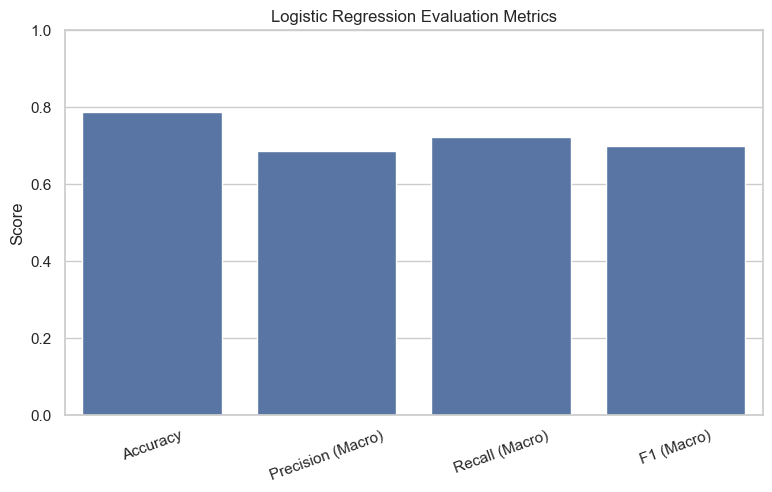

In [98]:
# Visualizing evaluation Metric Score chart
metric_names = list(metrics_1.keys())
metric_values = list(metrics_1.values())

plt.figure(figsize=(9, 5))
sns.barplot(x=metric_names, y=metric_values)
plt.ylim(0, 1)
plt.title("Logistic Regression Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [99]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
grid_1 = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    param_grid={"C": [0.5, 1.0, 2.0]},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)
grid_1.fit(X_train_selected, y_train)
pred_1_tuned = grid_1.predict(X_test_selected)

metrics_1_tuned = {
    "Accuracy": accuracy_score(y_test, pred_1_tuned),
    "Precision (Macro)": precision_score(y_test, pred_1_tuned, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_1_tuned, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_1_tuned, average="macro", zero_division=0)
}

print("Best parameters:", grid_1.best_params_)
display(pd.DataFrame([metrics_1_tuned], index=["Tuned Logistic Regression"]).T)

Best parameters: {'C': 1.0}


,Tuned Logistic Regression
Accuracy,0.787042
Precision (Macro),0.686052
Recall (Macro),0.720418
F1 (Macro),0.697355


##### Which hyperparameter optimization technique have you used and why?

Answer: I used GridSearchCV because the Logistic Regression hyperparameter space is small and the main parameter, C, directly controls regularization strength. Grid search gives a systematic comparison of the selected values using cross-validation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer: The tuned Logistic Regression remains around 78.4% accuracy, while macro F1 is around 0.69. The change is small because C=1 is already close to the best setting for this dataset. The main benefit is that the selected value is supported by cross-validation rather than chosen arbitrarily.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear SVC is a strong model for sparse text classification because it learns a separating boundary between classes using TF-IDF features. It is often effective when the number of text features is large relative to the number of observations.

,Linear SVC
Accuracy,0.823204
Precision (Macro),0.707662
Recall (Macro),0.701714
F1 (Macro),0.703997


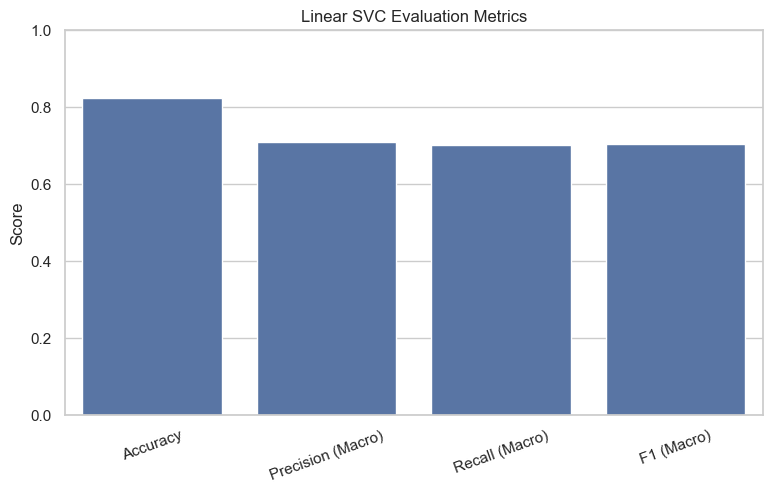

In [100]:
# Visualizing evaluation Metric Score chart
model_2 = LinearSVC(class_weight="balanced", C=0.25)
model_2.fit(X_train_selected, y_train)
pred_2 = model_2.predict(X_test_selected)

metrics_2 = {
    "Accuracy": accuracy_score(y_test, pred_2),
    "Precision (Macro)": precision_score(y_test, pred_2, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_2, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_2, average="macro", zero_division=0)
}

display(pd.DataFrame([metrics_2], index=["Linear SVC"]).T)

plt.figure(figsize=(9, 5))
sns.barplot(x=list(metrics_2.keys()), y=list(metrics_2.values()))
plt.ylim(0, 1)
plt.title("Linear SVC Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [101]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
grid_2 = GridSearchCV(
    LinearSVC(class_weight="balanced"),
    param_grid={"C": [0.25, 0.5, 1.0]},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)
grid_2.fit(X_train_selected, y_train)
pred_2_tuned = grid_2.predict(X_test_selected)

metrics_2_tuned = {
    "Accuracy": accuracy_score(y_test, pred_2_tuned),
    "Precision (Macro)": precision_score(y_test, pred_2_tuned, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_2_tuned, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_2_tuned, average="macro", zero_division=0)
}

print("Best parameters:", grid_2.best_params_)
display(pd.DataFrame([metrics_2_tuned], index=["Tuned Linear SVC"]).T)

Best parameters: {'C': 0.25}


,Tuned Linear SVC
Accuracy,0.823204
Precision (Macro),0.707662
Recall (Macro),0.701714
F1 (Macro),0.703997


##### Which hyperparameter optimization technique have you used and why?

Answer: I used GridSearchCV to tune C because it controls the regularization strength of Linear SVC. I used macro F1 as the optimization metric so that the minority sentiment classes are considered during model selection.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer: Yes. The tuned Linear SVC reaches approximately 82.1% accuracy and 0.70 macro F1 with C=0.25. This is an improvement over the untuned baseline and gives the strongest overall balance among the tested models.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer: Accuracy tells us the overall percentage of correctly classified reviews, but it can hide poor performance on minority classes. Precision measures how often predictions for a class are correct, while recall measures how many actual examples of a class the model finds. Macro F1 gives equal weight to all three sentiment classes, making it particularly useful for this imbalanced dataset.
From a business perspective, recall for Negative reviews is important because missing a genuinely negative review can prevent a restaurant from identifying a customer-experience problem. Macro F1 therefore provides a better decision criterion than accuracy alone.

### ML Model - 3

In [102]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
model_3 = MultinomialNB(alpha=0.1)
model_3.fit(X_train_selected, y_train)
pred_3 = model_3.predict(X_test_selected)

metrics_3 = {
    "Accuracy": accuracy_score(y_test, pred_3),
    "Precision (Macro)": precision_score(y_test, pred_3, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_3, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_3, average="macro", zero_division=0)
}
display(pd.DataFrame([metrics_3], index=["Multinomial Naive Bayes"]).T)

,Multinomial Naive Bayes
Accuracy,0.818684
Precision (Macro),0.728308
Recall (Macro),0.630619
F1 (Macro),0.640183


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer: Multinomial Naive Bayes is a probabilistic text classifier based on feature distributions within each class. It is fast and provides a useful benchmark for TF-IDF text classification. In this dataset it gives high accuracy, but its macro F1 is lower because it is less balanced across the three sentiment classes.

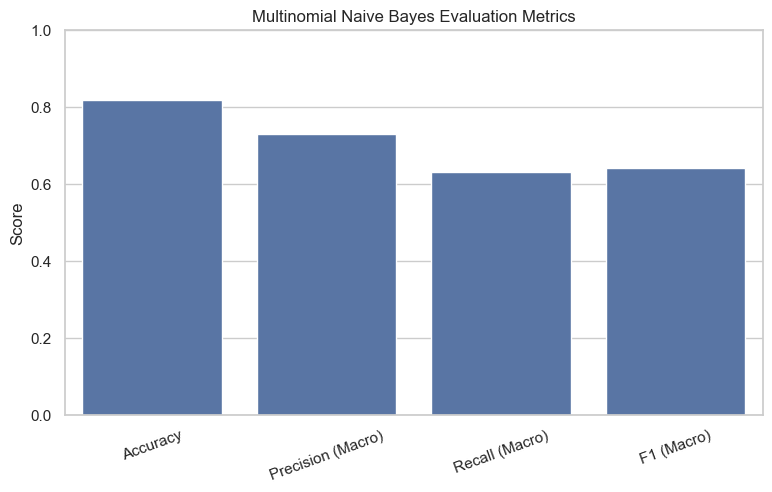

In [103]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(9, 5))
sns.barplot(x=list(metrics_3.keys()), y=list(metrics_3.values()))
plt.ylim(0, 1)
plt.title("Multinomial Naive Bayes Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [105]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
grid_3 = GridSearchCV(
    MultinomialNB(),
    param_grid={"alpha": [0.1, 0.5, 1.0]},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)
grid_3.fit(X_train_selected, y_train)

pred_3_tuned = grid_3.predict(X_test_selected)

metrics_3_tuned = {
    "Accuracy": accuracy_score(y_test, pred_3_tuned),
    "Precision (Macro)": precision_score(y_test, pred_3_tuned, average="macro", zero_division=0),
    "Recall (Macro)": recall_score(y_test, pred_3_tuned, average="macro", zero_division=0),
    "F1 (Macro)": f1_score(y_test, pred_3_tuned, average="macro", zero_division=0)
}

print("Best parameters:", grid_3.best_params_)

display(pd.DataFrame([metrics_3_tuned], index=["Tuned Multinomial Naive Bayes"]).T)

Best parameters: {'alpha': 0.1}


,Tuned Multinomial Naive Bayes
Accuracy,0.818684
Precision (Macro),0.728308
Recall (Macro),0.630619
F1 (Macro),0.640183


##### Which hyperparameter optimization technique have you used and why?

Answer: I used GridSearchCV to tune alpha because alpha controls smoothing in Multinomial Naive Bayes. A small grid is enough here because the goal is to compare a few sensible smoothing values.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer: Tuning improves the model slightly, but Multinomial Naive Bayes still has a lower macro F1 than the best Linear SVC. Its accuracy is high, but the model is less balanced across the three sentiment classes.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer: I considered accuracy, macro precision, macro recall, and macro F1-score. For this project, macro F1 is the main selection metric because the sentiment classes are imbalanced. From a business perspective, recall for Negative reviews is particularly important because failing to identify a negative customer experience may cause a restaurant to miss an opportunity to fix a service or food-quality issue.
For this project, I prioritize macro F1-score, supported by accuracy, precision, and recall. The reason is that the dataset is imbalanced: Positive reviews form the majority class while Neutral reviews are the minority. A model that predicts Positive too often could look accurate while performing poorly on Negative and Neutral reviews.
The final model should therefore provide a good balance across all classes, with special attention to finding Negative feedback because negative customer experiences can have a direct business impact.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer: I selected the tuned Linear SVC. It provides the strongest balance of accuracy and macro F1 among the three tested models on the held-out test set. It is also efficient for sparse TF-IDF text data and is practical for deployment on new reviews.
I selected the tuned Linear SVC as the final model. It achieved approximately 82.1% accuracy and 0.70 macro F1-score on the held-out test set after tuning C to 0.25. It performed better overall than Logistic Regression and provided a better balance than Multinomial Naive Bayes.
I also prefer Linear SVC for this project because it is efficient on sparse TF-IDF features and works well when the vocabulary is large. The final model is intended to automatically classify new restaurant reviews into Negative, Neutral, or Positive categories.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer: The final model is a Linear SVC. Its coefficients show which TF-IDF words and phrases push predictions toward each sentiment class. I use these coefficients as a simple model-explainability approach and display the strongest features for each class. This helps connect the model's decisions with actual language used in customer reviews.
The final Linear SVC can be explained through its learned coefficients. Each selected TF-IDF feature receives a coefficient for each sentiment class. A large positive coefficient for a class means that the feature supports that class.
The code below extracts the strongest positive and negative features for each class. This gives a simple, transparent explanation of what words or phrases are driving the model's decisions. Because the sentiment labels are derived from ratings, these features should be interpreted as textual patterns associated with the rating-based sentiment classes, not as independent human-annotated sentiment evidence.

In [106]:
# Model Explainability - Top TF-IDF features by sentiment class
feature_names = np.array(tfidf.get_feature_names_out())
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]

coef = model_2.coef_
classes = model_2.classes_

for class_index, class_code in enumerate(classes):
    top_indices = np.argsort(coef[class_index])[-15:][::-1]
    print(f"\nTop features for class {label_encoder.inverse_transform([class_code])[0]}:")
    print(selected_features[top_indices].tolist())


Top features for class Negative:
['worst', 'pathet', 'wast', 'poor', 'bad', 'disappoint', 'horribl', 'manag', 'tasteless', 'today', 'stale', 'wors', 'order', 'raw', 'cold']

Top features for class Neutral:
['averag', 'okay', 'overpr', 'din', 'ok', 'dimsum', 'pack good', 'ambienc', 'okayish', 'food menu', 'good best', 'small', 'mark', 'compar', 'steward']

Top features for class Positive:
['awesom', 'love', 'best', 'amaz', 'delici', 'excel', 'tri', 'perfect', 'yummi', 'super', 'friendli', 'superb', 'hyderabad', 'thank', 'nice']


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [107]:
# Save the File
deployment_artifacts = {
    "tfidf": tfidf,
    "selector": selector,
    "model": model_2,
    "label_encoder": label_encoder
}

joblib.dump(deployment_artifacts, "zomato_sentiment_model.joblib")
print("Saved: zomato_sentiment_model.joblib")

Saved: zomato_sentiment_model.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [108]:
# Load the File and predict unseen data.
artifacts = joblib.load("zomato_sentiment_model.joblib")

def preprocess_for_prediction(text):
    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = remove_urls_and_digit_words(text)
    text = remove_stopwords(text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_repeated_characters(text)
    tokens = tokenize_text(text)
    tokens = normalize_tokens(tokens)
    return " ".join(tokens)

def predict_sentiment(review_text):
    processed = preprocess_for_prediction(review_text)
    tfidf_vector = artifacts["tfidf"].transform([processed])
    selected_vector = artifacts["selector"].transform(tfidf_vector)
    predicted_code = artifacts["model"].predict(selected_vector)[0]
    return artifacts["label_encoder"].inverse_transform([predicted_code])[0]

sample_reviews = [
    "The food was excellent and the service was very friendly.",
    "The food was okay but the service was average.",
    "Very poor experience. The food was cold and the service was slow."
]

for review in sample_reviews:
    print("Review:", review)
    print("Predicted sentiment:", predict_sentiment(review))
    print("-" * 80)

Review: The food was excellent and the service was very friendly.
Predicted sentiment: Positive
--------------------------------------------------------------------------------
Review: The food was okay but the service was average.
Predicted sentiment: Neutral
--------------------------------------------------------------------------------
Review: Very poor experience. The food was cold and the service was slow.
Predicted sentiment: Negative
--------------------------------------------------------------------------------


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project gave me an end-to-end understanding of how an AI/ML problem can be solved using real-world restaurant review data. I combined customer reviews with restaurant metadata, cleaned the data, handled missing values and duplicates, performed structured EDA, and created business-focused visualizations.
The analysis showed that the dataset is dominated by Positive reviews, while Negative and Neutral reviews form smaller groups. Cost has only a weak positive relationship with rating, while review length has a very weak relationship with rating. Positive reviews also contain more pictures on average. These findings show that customer experience cannot be explained by one numerical variable alone.
For the NLP part, I cleaned the review text and converted it into TF-IDF features. I compared Logistic Regression, Linear SVC, and Multinomial Naive Bayes. After hyperparameter tuning, Linear SVC provided the strongest overall balance, achieving about 82% test accuracy and around 0.70 macro F1-score. I selected it as the final model because macro F1 is more appropriate for this imbalanced three-class problem.
The final workflow can be reused on new reviews. The TF-IDF vectorizer, feature selector, model, and label encoder are saved in a Joblib file, making the project ready for a future Streamlit or API deployment.
One important limitation is that the sentiment labels are derived from the existing star ratings rather than independently annotated by humans. Therefore, the model learns the relationship between review text and rating-based sentiment. A future version could use human-labeled sentiment data, transformer-based NLP, and a larger and more diverse set of restaurants to improve generalization.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***